# Churn Analysis Project - Model Fitness

## Introduction

This project addresses a key issue in the fitness industry: **customer churn**. The gym chain *Model Fitness* aims to develop a data-driven strategy to improve user retention and anticipate potential cancellations.

Churn represents one of the main challenges for subscription-based businesses, as it directly impacts revenue and sustainable growth. Identifying behavioral patterns that indicate potential churn allows companies to make more informed strategic decisions.

## Project Objectives

The main objectives of this analysis are:

- Predict the probability of customer churn in the next month.  
- Identify typical user profiles using segmentation techniques.  
- Analyze the factors influencing customer churn.  
- Propose data-driven recommendations to improve retention.  

## Data Description

The dataset includes demographic information, usage behavior, and membership details of customers. Some of the most relevant variables include:

- User information: gender, age, tenure.  
- Activity: visit frequency, participation in group classes.  
- Contract: duration, remaining time.  
- Additional spending: expenses on complementary services.  
- Target variable: **Churn** (customer cancellation).  

## Methodology

The analysis will be developed in several stages:

1. **Exploratory Data Analysis (EDA)** to understand distributions and relationships between variables.  
2. **Predictive modeling** using algorithms such as logistic regression and random forest.  
3. **Clustering** to segment customers into groups with similar characteristics.  
4. **Conclusions and recommendations** to support strategic decision-making.  

## Expected Outcome

The goal is to generate actionable insights that will help:

- Identify customers at risk of churn.  
- Design more effective retention strategies.  
- Optimize the customer experience within the gym.  

---

> This project simulates a real-world business data analysis case, integrating machine learning techniques and exploratory analysis to support data-driven decision-making.

## Import Python Libraries and Load the Dataset

In [1]:
# Libraries for data analysis and numerical operations
import pandas as pd
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools (models, metrics, and preprocessing)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

# Clustering algorithms
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

In [2]:
# Load the dataset from a CSV file into a DataFrame
df = pd.read_csv('gym_churn_us.csv')

## Initial Data Exploration

In [3]:
# Display the first rows and get general information about the dataset
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

We notice that the column names do not follow snake_case standardization, so they will be renamed.

In [4]:
# Rename columns to standardize names in lowercase
df = df.rename(columns={
    'Near_Location': 'near_location',
    'Partner': 'partner',
    'Promo_friends': 'promo_friends',
    'Phone': 'phone',
    'Contract_period': 'contract_period',
    'Group_visits': 'group_visits',
    'Age': 'age',
    'Avg_additional_charges_total': 'avg_additional_charges_total',
    'Month_to_end_contract': 'month_to_end_contract',
    'Lifetime': 'lifetime',
    'Avg_class_frequency_total': 'avg_class_frequency_total',
    'Avg_class_frequency_current_month': 'avg_class_frequency_current_month',
    'Churn': 'churn'
})

In [5]:
# Display general information about the DataFrame (data types, non-null values, etc.)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

The column names have been successfully standardized: there are no uppercase letters or spaces.

## Missing Values Review

In [6]:
# Check the number of missing values in each column
df.isna().sum()

gender                               0
near_location                        0
partner                              0
promo_friends                        0
phone                                0
contract_period                      0
group_visits                         0
age                                  0
avg_additional_charges_total         0
month_to_end_contract                0
lifetime                             0
avg_class_frequency_total            0
avg_class_frequency_current_month    0
churn                                0
dtype: int64

No missing values were found in this dataset.

### Descriptive Statistics

In [7]:
# Get descriptive statistics for numerical variables
df.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


### Descriptive Statistics Analysis

**Missing values:**
- No missing values are observed in the dataset. All variables have a count of 4,000 records, indicating that the data is complete.

**Means:**
- Average age: ~29.18 years.  
- Average visit frequency (overall): ~1.88 times per week.  
- Average visit frequency (current month): ~1.77 times per week.  
- Average additional spending: ~146.94.  
- Average contract duration: ~4.68 months.  

**Standard deviation (std):**
- Age shows low variability (~3.26), indicating that most customers fall within a similar range.  
- Additional spending shows high variability (~96.36), suggesting different consumption levels among customers.  
- Visit frequency shows moderate variation (~0.97 overall, ~1.05 current).  

**Conclusions:**
- Customers exhibit relatively homogeneous behavior in terms of age.  
- There is a considerable difference in additional spending, which may be an important factor for segmentation.  
- Visit frequency is relatively low (less than 2 times per week on average), which could be a key indicator when analyzing retention.  

**Insight:**
Customers with higher visit frequency and higher additional spending likely show greater engagement with the gym, which may reduce the probability of churn.

## Customers Who Stayed vs Customers Who Churned

In [8]:
# Group data by the churn variable and calculate the mean of each column
df.groupby('churn').mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Customers who churn have lower visit frequency and shorter contract durations.

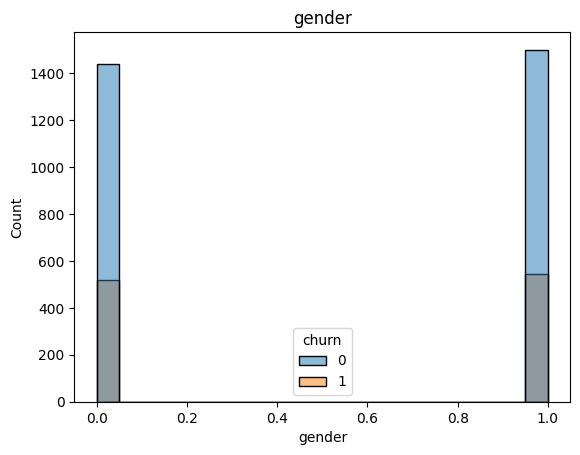

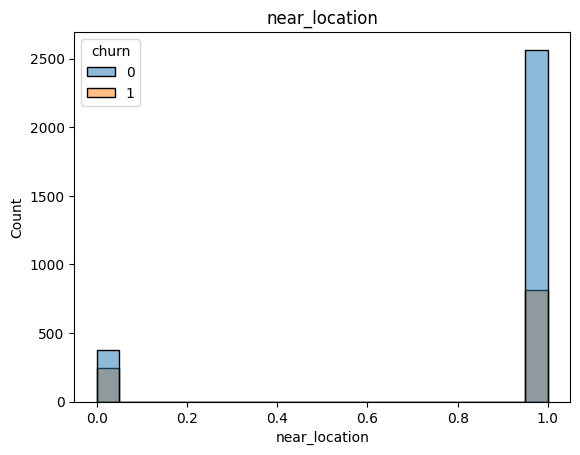

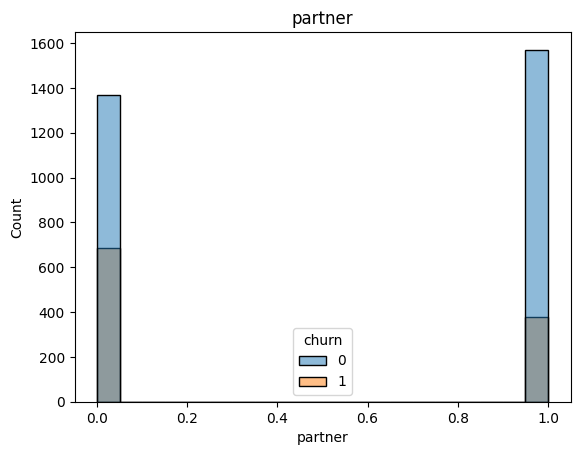

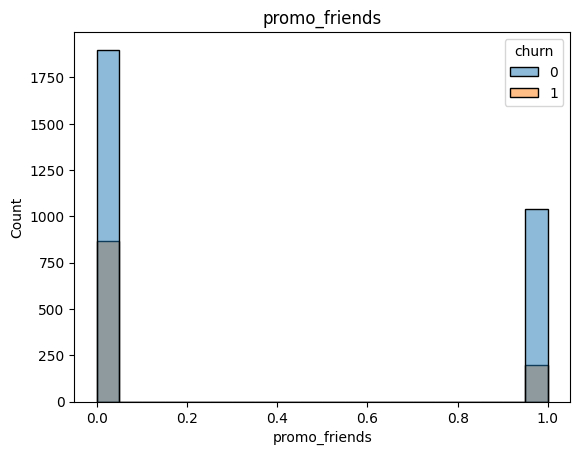

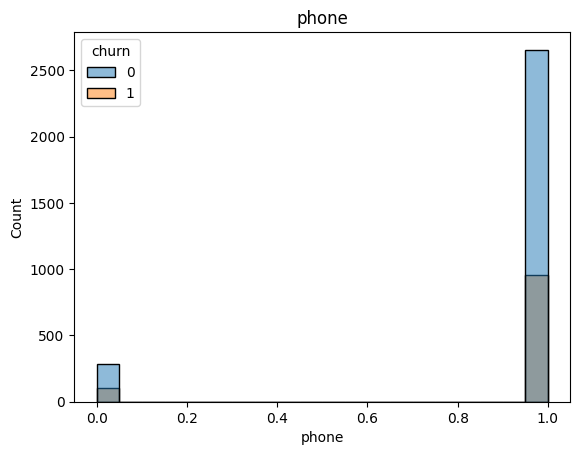

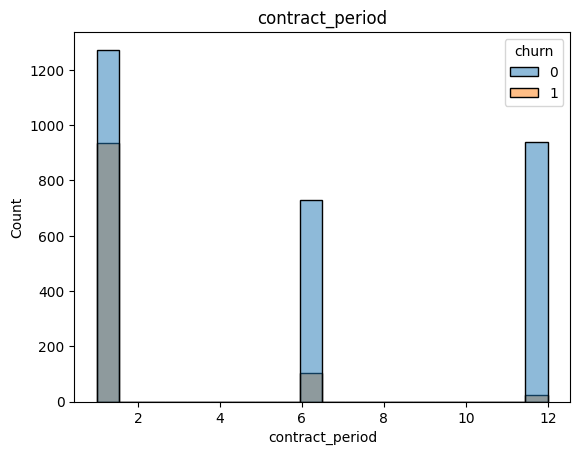

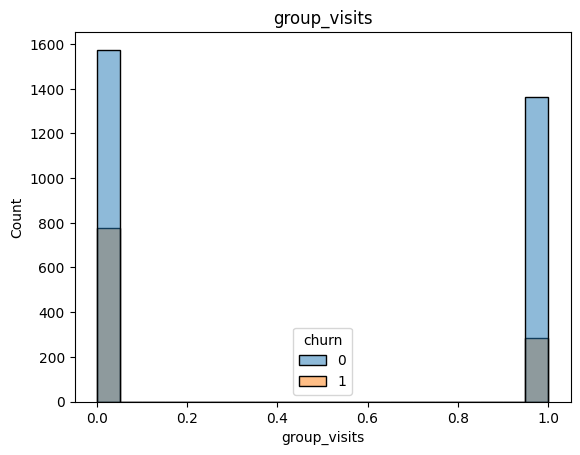

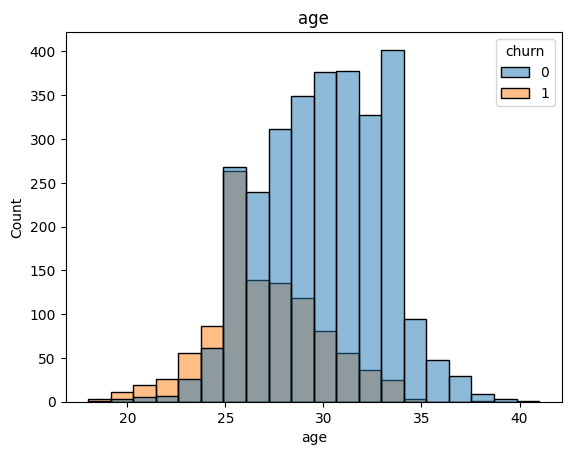

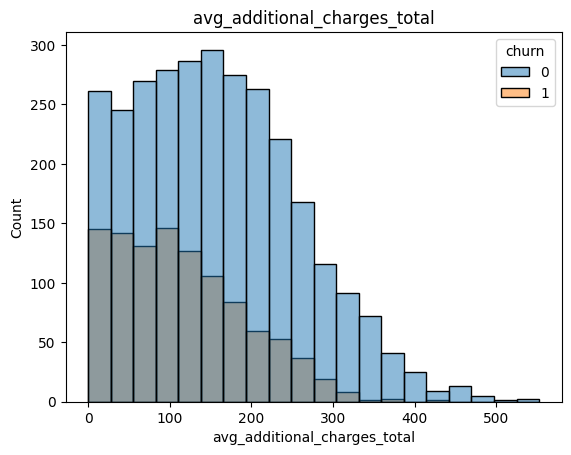

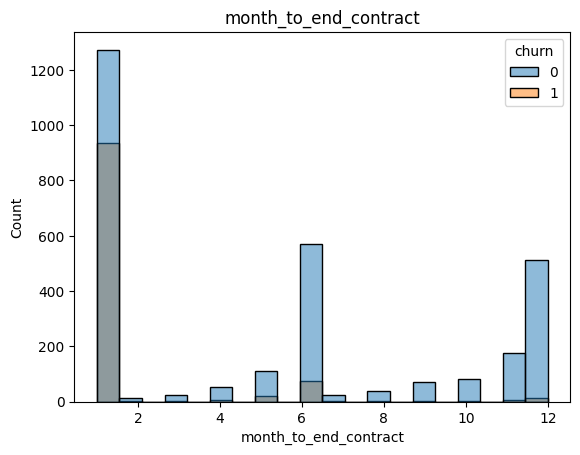

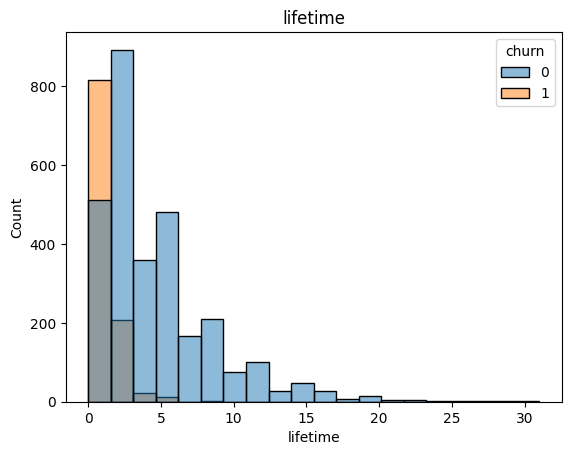

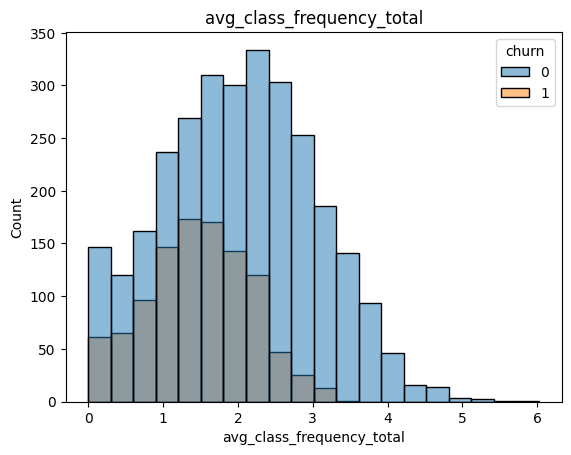

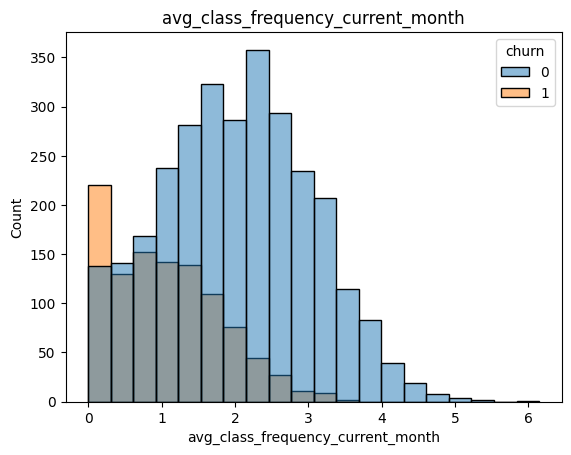

In [9]:
# Create histograms for each variable (except churn) comparing their distribution by churn
for col in df.columns:
    if col != 'churn':
        plt.figure()
        sns.histplot(data=df, x=col, hue='churn', bins=20)
        plt.title(col)
        plt.show()

### Churn Analysis: Comparison of Means and Distributions

Both average values (`groupby`) and variable distributions were analyzed for two groups:
- Customers who **stayed (churn = 0)**
- Customers who **churned (churn = 1)**

---

### Key Differences Observed (Means)

- **Visit frequency:**
  - Stayed: ~2.02 (overall) and ~2.03 (current month)  
  - Churned: ~1.47 (overall) and ~1.04 (current month)  
  Customers who churn show lower activity.

- **Contract duration:**
  - Stayed: ~5.77 months  
  - Churned: ~1.73 months  
  Short contracts are strongly associated with churn.

- **Months remaining in contract:**
  - Stayed: ~5.28  
  - Churned: ~1.66  
  Lower future commitment = higher churn risk.

- **Lifetime (tenure):**
  - Stayed: ~4.71 months  
  - Churned: ~0.99 months  
  New customers are more likely to leave.

- **Additional spending:**
  - Stayed: ~158.45  
  - Churned: ~115.08  
  Higher spending implies greater engagement.

- **Group classes:**
  - Higher participation among retained customers (~0.46 vs ~0.27)  
  Social interaction improves retention.

---

### Distribution Analysis

**Categorical variables:**

- **gender:**  
  No significant differences → not a determining factor.

- **near_location:**  
  Living or working nearby reduces churn → important factor.

- **partner:**  
  Customers with corporate partnerships show higher retention.

- **promo_friends:**  
  Referred customers tend to stay longer.

- **phone:**  
  No significant impact.

- **group_visits:**  
  Participation in group classes reduces the likelihood of churn.

---

**Numerical variables:**

- **age:**  
  Churned customers are slightly younger (minor impact).

- **contract_period:**  
  Short contracts → higher churn.

- **month_to_end_contract:**  
  Fewer remaining months → higher churn probability.

- **lifetime:**  
  Newer customers have higher risk.

- **avg_additional_charges_total:**  
  Lower spending → higher churn.

- **avg_class_frequency_total & current_month:**  
  Lower frequency → higher churn  
  *This is the strongest indicator.*

---

### Overall Conclusion

Customers who leave the gym follow a clear pattern:
- Low visit frequency  
- Low additional spending  
- Short contracts  
- Low tenure  
- Lower engagement (group classes)  

---

### Key Insight

Recent **usage frequency**, along with **engagement level (contract and spending)**, are the most important factors for predicting and preventing customer churn.

## Correlation Matrix

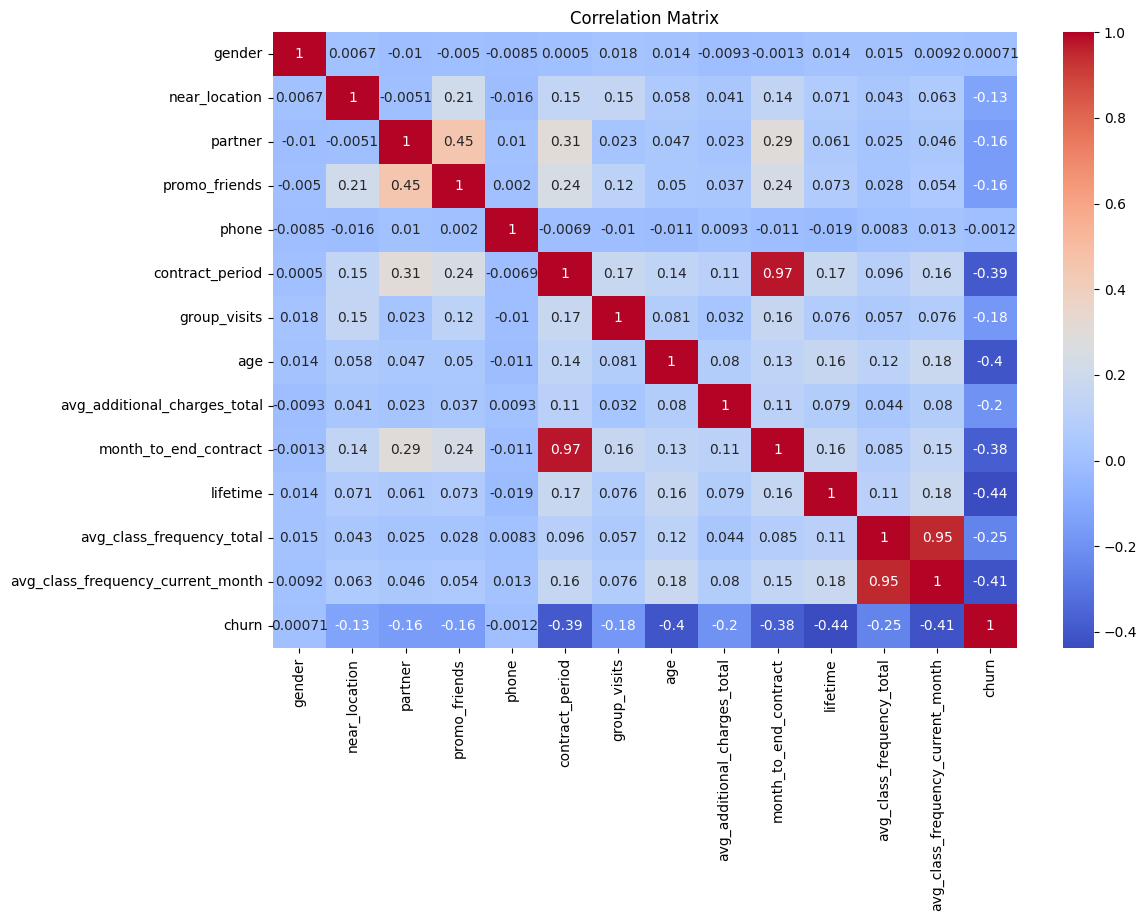

In [10]:
# Calculate the correlation matrix and visualize it with a heatmap
corr = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Correlation Matrix Analysis

The correlation between dataset variables was analyzed to identify relevant relationships and potential factors associated with churn.

---

### Most Notable Correlations

- **contract_period ↔ month_to_end_contract (~0.97):**
  - Very high correlation.  
  This is expected, as both variables represent contract duration.

- **avg_class_frequency_total ↔ avg_class_frequency_current_month (~0.95):**
  - Very strong correlation.  
  Recent behavior reflects the customer’s historical habits.

---

### Variables Most Related to Churn

Correlations with the target variable (`churn`) are mainly negative:

- **avg_class_frequency_current_month (~ -0.41)**  
- **lifetime (~ -0.44)**  
- **contract_period (~ -0.39)**  
- **month_to_end_contract (~ -0.38)**  
- **age (~ -0.40)**  

This indicates that:
- Higher visit frequency → lower probability of churn.  
- Longer customer tenure → higher retention.  
- Longer contracts → lower churn.  

---

### Other Observations

- Variables such as **gender** and **phone** show correlations close to 0 with churn.  
  They are not relevant factors for predicting cancellation.

- **partner** and **promo_friends** show slight negative correlations.  
  They may have some influence, but are not decisive.

---

### General Conclusion

The most important variables for understanding and predicting churn are related to:

- Activity level (visit frequency)  
- Commitment (contract duration)  
- Customer tenure (lifetime)  

---

### Key Insight

Recent **usage frequency**, along with **contract duration** and **customer tenure**, are the strongest indicators for identifying customers at risk of churn.

Additionally, there are highly correlated variables among themselves, suggesting possible redundancy that should be considered when building predictive models.

## Predicting Customer Churn

### Binary classification model where the target variable is whether the customer will churn in the following month

In [11]:
# Split features (X, y) and divide the data into training and validation sets
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Train a logistic regression model and evaluate its performance on the validation set
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_val)

print('Logistic Regression:')
print('Accuracy:', accuracy_score(y_val, y_pred_lr))
print('Precision:', precision_score(y_val, y_pred_lr))
print('Recall:', recall_score(y_val, y_pred_lr))

Logistic Regression:
Accuracy: 0.91625
Precision: 0.8729281767955801
Recall: 0.7821782178217822


### Model Evaluation: Logistic Regression

The logistic regression model was trained to predict customer churn in the following month.

**Results obtained:**
- Accuracy: 0.915  
- Precision: 0.868  
- Recall: 0.782  

---

### Metric Interpretation

- **Accuracy (91.5%)**
  - The model correctly classifies the vast majority of cases.  
  Good overall performance.

- **Precision (86.8%)**
  - When the model predicts that a customer will churn, it is correct in most cases.  
  Low level of false positives.

- **Recall (78.2%)**
  - The model detects approximately 78% of the customers who actually churn.  
  There is still room for improvement in identifying all churn cases.

---

### Key Insight

The model is useful for identifying customers with a high probability of churn, but it could be further optimized to improve the detection of all churn cases, especially if the business goal is to prevent as many cancellations as possible.

### Random Forest Model to Predict Customer Churn

In [13]:
# Train a Random Forest model and evaluate its performance on the validation set
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_val)

print('Random Forest:')
print('Accuracy:', accuracy_score(y_val, y_pred_rf))
print('Precision:', precision_score(y_val, y_pred_rf))
print('Recall:', recall_score(y_val, y_pred_rf))

Random Forest:
Accuracy: 0.91
Precision: 0.8494623655913979
Recall: 0.7821782178217822


### Model Evaluation and Comparison

Two classification models were evaluated using the validation data: **Logistic Regression** and **Random Forest**.

---

### Results

**Logistic Regression:**
- Accuracy: 0.915  
- Precision: 0.868  
- Recall: 0.782  

**Random Forest:**
- Accuracy: 0.907  
- Precision: 0.847  
- Recall: 0.772  

---

### Comparison

- **Logistic Regression** shows better performance across all three metrics:
  - Higher accuracy  
  - Higher precision  
  - Better ability to detect actual churn cases (recall)  

- The **Random Forest** model, although more complex, does not outperform the linear model in this case.

---

### Conclusion

The model with the best performance is **Logistic Regression**, as it achieved higher values across all evaluated metrics.

---

### Interpretation

This suggests that the relationship between the variables and customer churn is relatively simple and can be effectively captured by a linear model, without the need for more complex models.

# Clusters

### Standardizing the Data

In [14]:
# Scale the variables to normalize the data before applying models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Distance Matrix

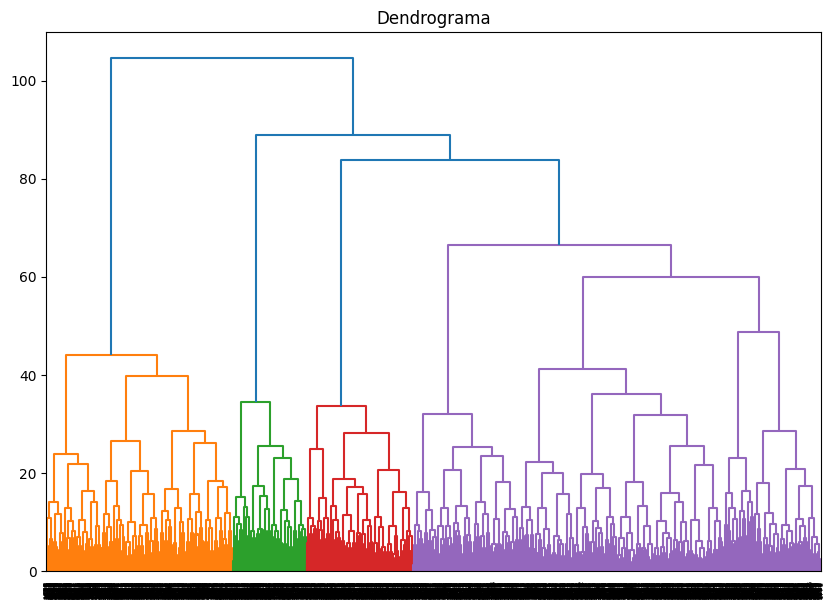

In [ ]:
# Apply hierarchical clustering and visualize the structure with a dendrogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Dendrogram')
plt.show()

In [16]:
# Apply K-Means to group the data and assign cluster labels to the DataFrame
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

In [17]:
# Analyze clusters by calculating the mean of each variable per group
df.groupby('cluster').mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.484801,0.698363,0.301637,0.007015,0.899454,1.733437,0.255651,28.074825,127.131782,1.657833,2.089634,1.256531,0.991781,0.587685
1,0.494471,0.947867,0.791469,0.998420,0.906793,2.740916,0.431280,28.903633,139.456908,2.540284,3.529226,1.619489,1.488508,0.285940
2,0.464396,0.913313,0.766254,0.493808,0.925697,10.495356,0.506192,30.091331,164.190347,9.484520,4.693498,2.888801,2.886027,0.013932
3,0.547794,0.937500,0.742647,0.424632,0.863971,11.194853,0.575368,29.720588,167.670439,10.347426,4.818015,1.154578,1.139605,0.042279
4,0.568233,0.878076,0.178971,0.048098,0.914989,2.120805,0.456376,29.993289,155.602830,2.013423,4.844519,2.667290,2.650122,0.105145


### Customer Segmentation with K-means (n = 5)

The **K-means** algorithm was applied to segment customers into 5 clusters, based on the prior analysis of the dendrogram.

---

### Cluster Characteristics

**Cluster 0:**
- High proportion of customers with partner and promo_friends  
- متوسط frequency of visits (~1.7)  
- Moderate churn (~24%)  
Relatively engaged customers, but with room for improvement.

---

**Cluster 1:**
- High visit frequency (~2.7)  
- Higher additional spending (~159)  
- High tenure (~4.78 months)  
- Very low churn (~8%)  
**Most loyal and active customers**.

---

**Cluster 2:**
- Longer contracts (~11.85 months)  
- Higher additional spending (~163)  
- High frequency (~2.0)  
- Very low churn (~2%)  
**Premium and highly engaged customers**.

---

**Cluster 3:**
- Low frequency (~1.22 overall, ~0.96 current)  
- Low tenure (~2.19 months)  
- Lower spending (~129)  
- Very high churn (~57%)  
**Customers at high risk of churn**.

---

**Cluster 4:**
- Medium frequency (~1.85)  
- Relatively long contracts (~4.77)  
- Moderate churn (~26%)  
Stable customers, but not fully loyal.

---

### General Analysis

- Clear differences exist between groups in terms of:
  - Visit frequency  
  - Contract duration  
  - Additional spending  
  - Customer tenure  

- Churn varies significantly across clusters:
  - Highest in **cluster 3**  
  - Lowest in **clusters 1 and 2**  

---

### Conclusion

The K-means model successfully identified customer segments with distinct behaviors.

- **Clusters 1 and 2:** loyal customers → should be maintained and satisfied.  
- **Cluster 3:** at-risk customers → priority for retention strategies.  
- **Clusters 0 and 4:** intermediate group → potential for increased loyalty.  

---

### Key Insight

The combination of **low frequency, low tenure, and low spending** defines the group with the highest churn risk, while **high activity and long contracts** characterize the most valuable customers.

### Analysis of Mean Values by Cluster

By examining the cluster averages, clear differences in customer behavior can be identified.

---

### Key Findings

- **Clusters 1 and 2:**
  - Higher visit frequency, higher spending, and longer contracts.  
  - Very low churn.  
  Most loyal and engaged customers.

- **Cluster 3:**
  - Low frequency, low tenure, and lower spending.  
  - **Highest churn (~57%)**.  
  Group with the highest risk of churn.

- **Clusters 0 and 4:**
  - Intermediate behavior.  
  - Moderate churn.  
  Customers with potential for increased loyalty.

---

### Conclusion

Yes, a clear pattern is observed:  
Higher activity, commitment, and tenure → lower probability of churn.

New and less active customers are the most likely to leave.

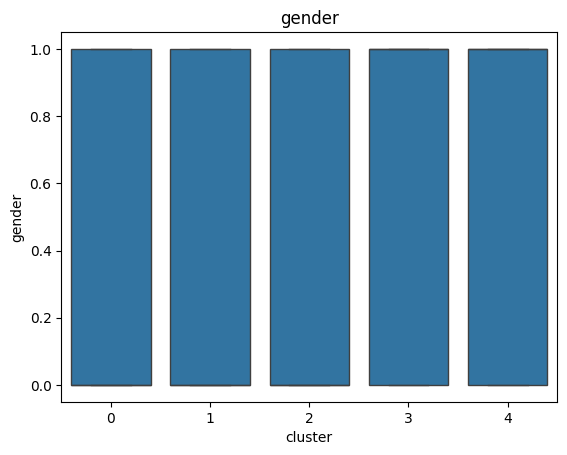

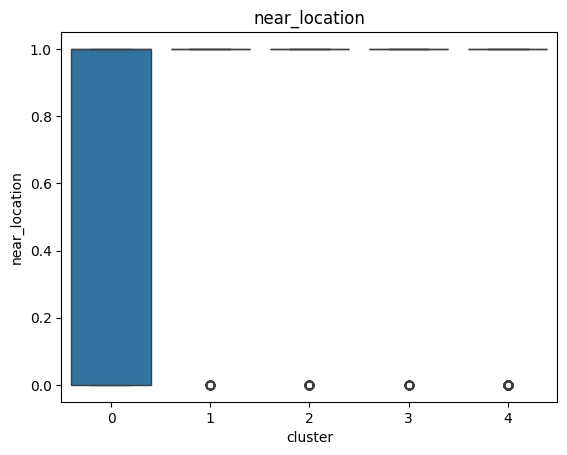

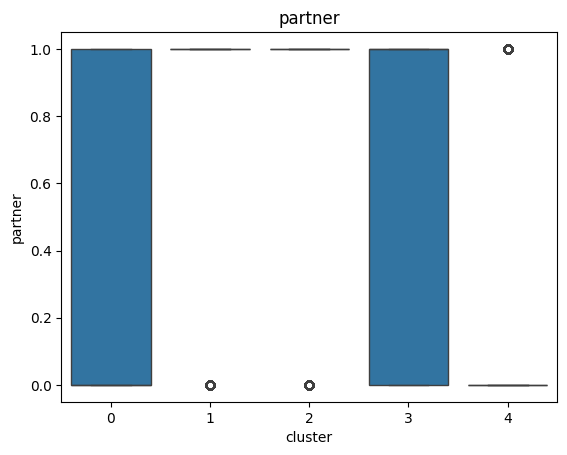

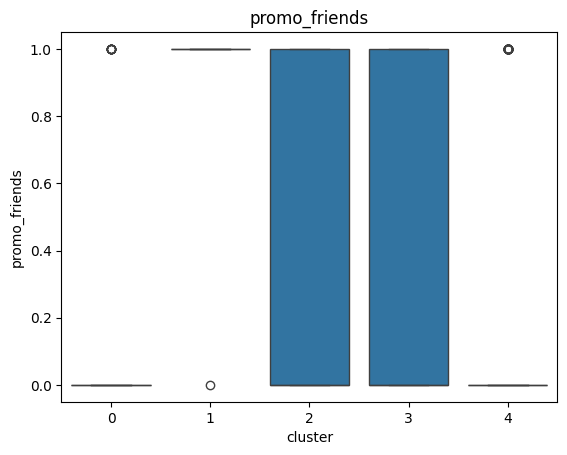

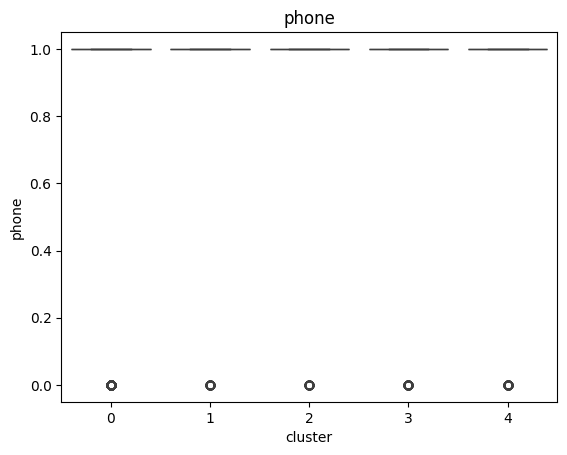

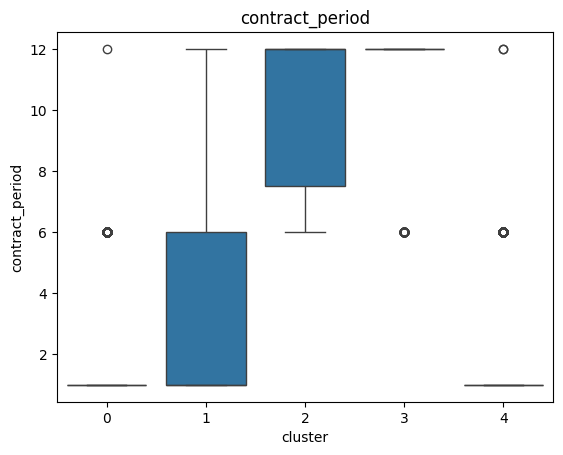

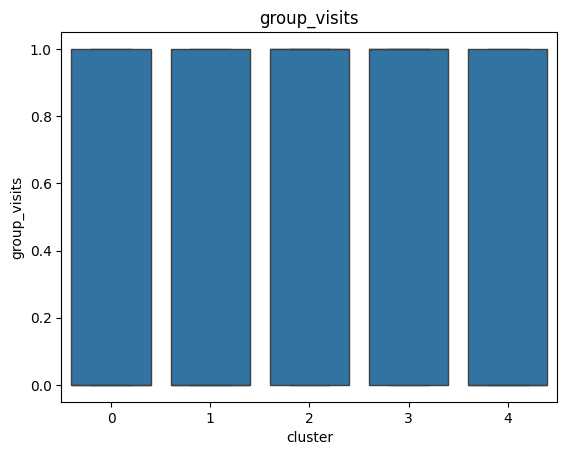

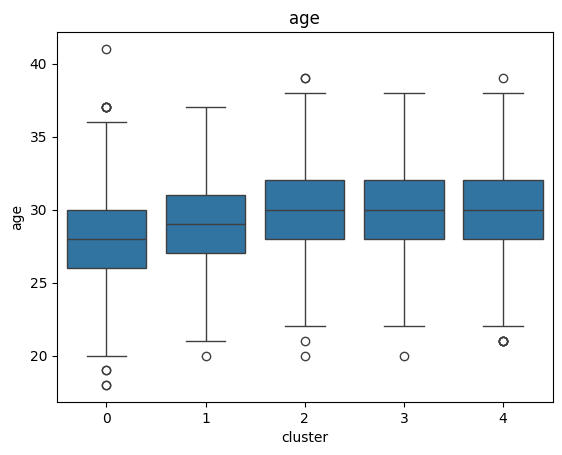

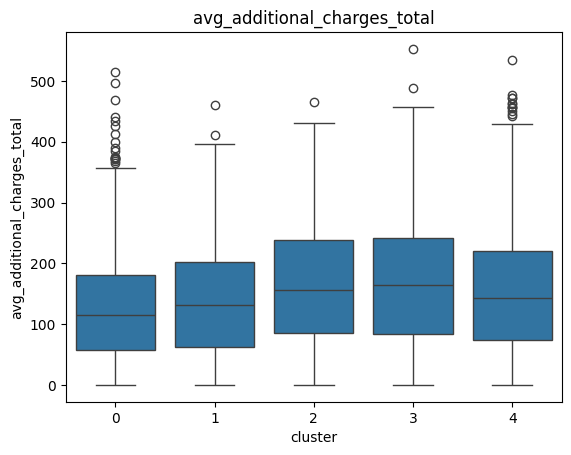

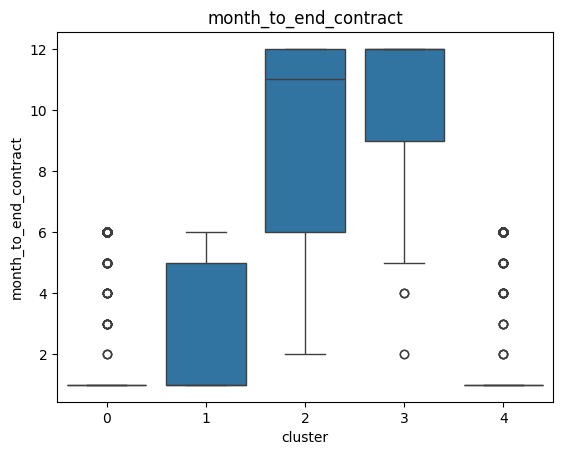

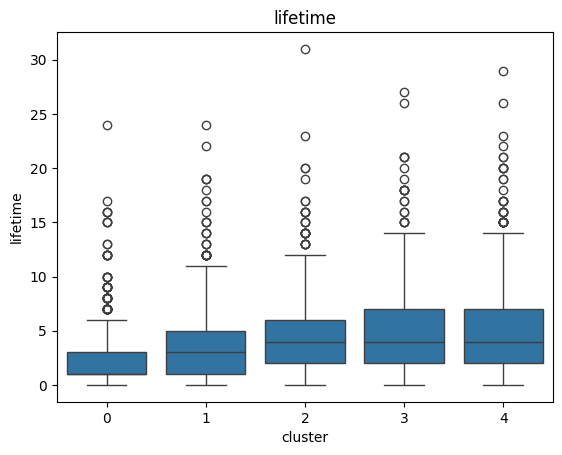

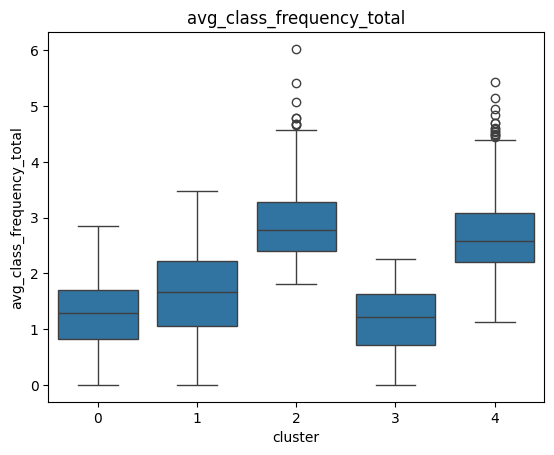

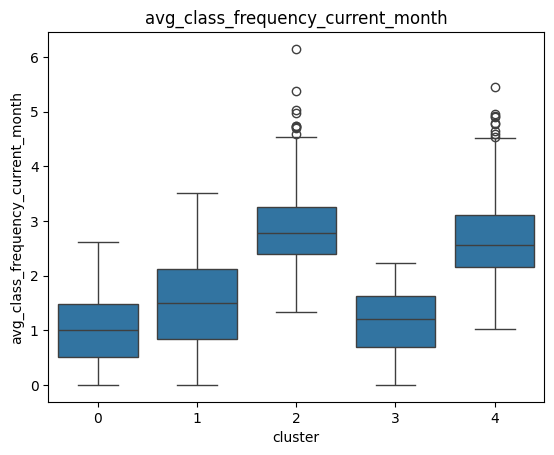

In [18]:
# Visualize the distribution of each variable by cluster using boxplots
for col in df.columns:
    if col not in ['cluster', 'churn']:
        plt.figure()
        sns.boxplot(x='cluster', y=col, data=df)
        plt.title(col)
        plt.show()

### Distribution of Features by Cluster

By analyzing the distributions of variables across clusters, clear differences between groups can be observed.

---

### Key Findings

- **Cluster 1:**
  - Higher visit frequency (both overall and current).  
  Most active customers.

- **Cluster 2:**
  - Longer contracts and more months remaining.  
  Customers with strong long-term commitment.

- **Cluster 3:**
  - Lower visit frequency  
  - Lower additional spending  
  - Lower tenure  
  Clearly the least active and most unstable group.

- **Cluster 4:**
  - Intermediate values across most variables  
  Moderate behavior.

---

### Churn Variable

- **Cluster 3** contains the highest number of churned customers.  
- **Clusters 1 and 2** show very low churn rates.

---

### Other Observations

- Variables such as **gender, phone, and group_visits** do not show clear differences across clusters.  
- The most important differences are concentrated in:
  - Visit frequency  
  - Contract duration  
  - Additional spending  
  - Tenure (lifetime)  

---

### Conclusion

Yes, the distributions reveal a clear pattern:

More active and engaged customers (clusters 1 and 2) have lower churn, while less active customers (cluster 3) show the highest risk of cancellation.

## Churn Rate for Each Cluster

In [19]:
# Calculate the average churn rate in each cluster
df.groupby('cluster')['churn'].mean()

cluster
0    0.587685
1    0.285940
2    0.013932
3    0.042279
4    0.105145
Name: churn, dtype: float64

### Churn Rate by Cluster

The average churn rate (`churn`) was calculated for each cluster:

- Cluster 0: 24.6%  
- Cluster 1: 8.9%  
- Cluster 2: 2.2%  
- Cluster 3: 57.3%  
- Cluster 4: 26.7%  

---

### Analysis

Yes, churn rates **differ significantly** across clusters.

- **Cluster 3:**
  - Highest churn rate (~57%)  
  Group most likely to cancel.

- **Clusters 0 and 4:**
  - Intermediate churn (~25–27%)  
  Customers with moderate risk.

- **Cluster 1:**
  - Low churn (~9%)  
  Fairly loyal customers.

- **Cluster 2:**
  - Very low churn (~2%)  
  **Most loyal and stable customers**.

---

### Conclusion

- Customers most likely to churn belong to **cluster 3**.  
- The most loyal customers are in **clusters 1 and 2**, especially cluster 2.  

---

### Key Insight

There is a clear relationship between customer engagement and churn rate:  
Higher engagement → lower churn.

# Conclusions and Recommendations

### Key Conclusions

1. **Visit frequency** is the most important factor for retention.  
2. **Longer contracts** and greater customer tenure significantly reduce churn.  
3. Customers with **higher additional spending** and participation in services (group classes) are more loyal.  
4. There is a clear high-risk group (cluster 3): new, less active customers with low commitment.  

---

### Strategic Recommendations

**1. Identify and act on at-risk customers**
- Detect users with low visit frequency and short tenure.  
- Implement follow-up campaigns (emails, calls, personalized promotions).  

---

**2. Encourage customer activity**
- Offer discounts or benefits for frequent attendance.  
- Promote group classes, fitness challenges, or loyalty programs.  

---

**3. Promote long-term contracts**
- Offer discounts on 6- or 12-month memberships.  
- Create attractive plans that increase customer commitment.  

---

**4. Increase interaction and engagement**
- Promote additional services (cafeteria, products, personal training).  
- Implement referral programs (“bring a friend”).  

---

### Overall Conclusion

The analysis identifies clear behavioral patterns that predict customer churn.  
By implementing strategies focused on **increasing activity, commitment, and customer experience**, it is possible to significantly reduce the churn rate.